# Delay-space comparison with horizon inset

This notebook uses `utils_Vtau2.py` to produce:

- upper left: full delay-spectrum curves;
- upper right: delay-amplitude histograms;
- lower left: full ratio curve with a horizon-range inset;
- lower right, upper panel: ratio histogram for \(0 \leq |\tau| \leq 4000\) ns;
- lower right, lower panel: ratio histogram for \(0 \leq |\tau| \leq \tau_{\rm horizon}\).


In [1]:
import glob
import importlib
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import gpytorch

from pyuvdata import UVData
import bayeslim as ba
import gprlim
from gprlim import kernels
from bayeslim.fft import FFT


# Local modules
sys.path.append("./")
sys.path.append("../../")

import utils_load
from utils_load import save_vd_inp, load_vd_inp

import gp_utils
importlib.reload(gp_utils)

import utils_Vtau2
importlib.reload(utils_Vtau2)

from utils_Vtau2 import (
    coherent_time_average,
    create_delay_figure,
    get_delay_quantities,
    get_ratio_hist_values,
    get_horizon_delay_ns,
    plot_delay_histograms,
    plot_reference_delay_curves,
    plot_method_curves,
    plot_ratio_inset,
    plot_ratio_histogram,
    make_ratio_label,
    format_delay_axis,
    format_delay_hist_axis,
    format_ratio_axis,
    format_ratio_inset_axis,
    format_ratio_hist_axis,
    finalize_delay_figure,
)


print("gprlim path:")
print(gprlim.__file__)

print("\nutils_load module path:")
print(inspect.getmodule(save_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)

print("\nutils_Vtau2 path:")
print(utils_Vtau2.__file__)


gprlim path:
/Users/alliswell48/gprlim/gprlim/__init__.py

utils_load module path:
/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/utils_load.py

gp_utils path:
/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/../../gp_utils.py

utils_Vtau2 path:
/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/utils_Vtau2.py


In [2]:
gpytorch.settings.max_cholesky_size._set_value(1_000)
torch.set_default_dtype(torch.float64)

device = "cpu"


## Analysis settings


In [3]:
# ============================================================
# 1. Input data
# ============================================================

flag_file = "gpr_data/version2/zen.h6c_idr3.2459951.flag_waterfall_round2.npz"

freq_chans = range(0, 600)
time_ints = range(80, 1680)

dfile = "gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5"

# Coupled simulation alternative:
# dfile = sorted(
#     glob.glob(
#         "gpr_data/version2/zen.h6c_idr2_validation.24582*.sum.coupled.h5"
#     )
# )


# ============================================================
# 2. Optional data modifications
# ============================================================

inflate_data = False
add_gains = False
add_noise = False
add_reflection = False


# ============================================================
# 3. Inpainting methods
# ============================================================

inpaint_method_all = ["2d", "2d_1d", "1d_1d", "freq"]

# Other possible choices:
# inpaint_method_all = ["2d", "2d_1d", "1d_1d", "freq"]


# ============================================================
# 4. Time chunk size
# ============================================================

Ntime_chunks = 200


# ============================================================
# 5. Real flags
# ============================================================

add_real_flags = True


# ============================================================
# 6. Simulated flag patterns
# ============================================================

flag_types_all = [
    None,
    "narrowband_full_time",
    "wideband_full_time",
    "ultraband_short_time",
    "fullband_short_time",
    "narrowband_short_time",
    "narrowband_long_time",
    "wideband_long_time",
    "randn",
]


# ============================================================
# 7. Polarization and baselines
# ============================================================

polsi = "ee"
blall = [(0, 1), (0, 5), (0, 10)]


# ============================================================
# 8. Saved inpainting results
# ============================================================

inpaint_root_dir = (
    "/Volumes/YUNYUNShao/"
    "radio_gpr_work_great_lake/"
    "2.shao_plus_real_flag/inpaint_results"
)


## Load autocorrelation and metadata


In [4]:
vd_auto, meta_auto = gp_utils.load_uvdata(
    dfile,
    bls=[(0, 0)],
    pols=[polsi],
    time_ints=time_ints,
    freq_chans=freq_chans,
)

autocorr = vd_auto.data[0, 0]

freqs = meta_auto["freqs"] / 1e6
lsts = meta_auto["lsts"]
times = (meta_auto["times"] - meta_auto["times"][0]) * 24 * 3600

Ntimes = len(times)
Nfreqs = len(freqs)

reds = meta_auto["reds"]
antp = meta_auto["antp"]

ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

red_bls = meta_auto["bls"]
all_pols = meta_auto["pols"]

integration_time_s = np.diff(meta_auto["times"])[0] * 24 * 3600
channel_width_hz = np.diff(meta_auto["freqs"])[0]

noise_amp = autocorr.real / np.sqrt(
    integration_time_s * channel_width_hz
)

print("Ntimes:", Ntimes)
print("Nfreqs:", Nfreqs)
print("Polarization:", polsi)


Ntimes: 1600
Nfreqs: 600
Polarization: ee


## Main baseline, flag-pattern, and method loops



Baseline: (0, 5)
Baseline length: 73.040 m
Horizon delay: 243.466 ns


Antenna pair (1, 6) does not have any data associated with it.
Antenna pair (2, 7) does not have any data associated with it.
Antenna pair (3, 8) does not have any data associated with it.
Antenna pair (4, 9) does not have any data associated with it.
Antenna pair (5, 10) does not have any data associated with it.
Antenna pair (11, 16) does not have any data associated with it.
Antenna pair (12, 17) does not have any data associated with it.
Antenna pair (13, 18) does not have any data associated with it.
Antenna pair (14, 19) does not have any data associated with it.
Antenna pair (15, 20) does not have any data associated with it.
Antenna pair (16, 21) does not have any data associated with it.
Antenna pair (23, 28) does not have any data associated with it.
Antenna pair (24, 29) does not have any data associated with it.
Antenna pair (25, 30) does not have any data associated with it.
Antenna pair (26, 31) does not have any data associated with it.
Antenna pair (27, 32) does not hav

Plotting: Real Flags


Attempt to set non-positive ylim on a log-scaled axis will be ignored.


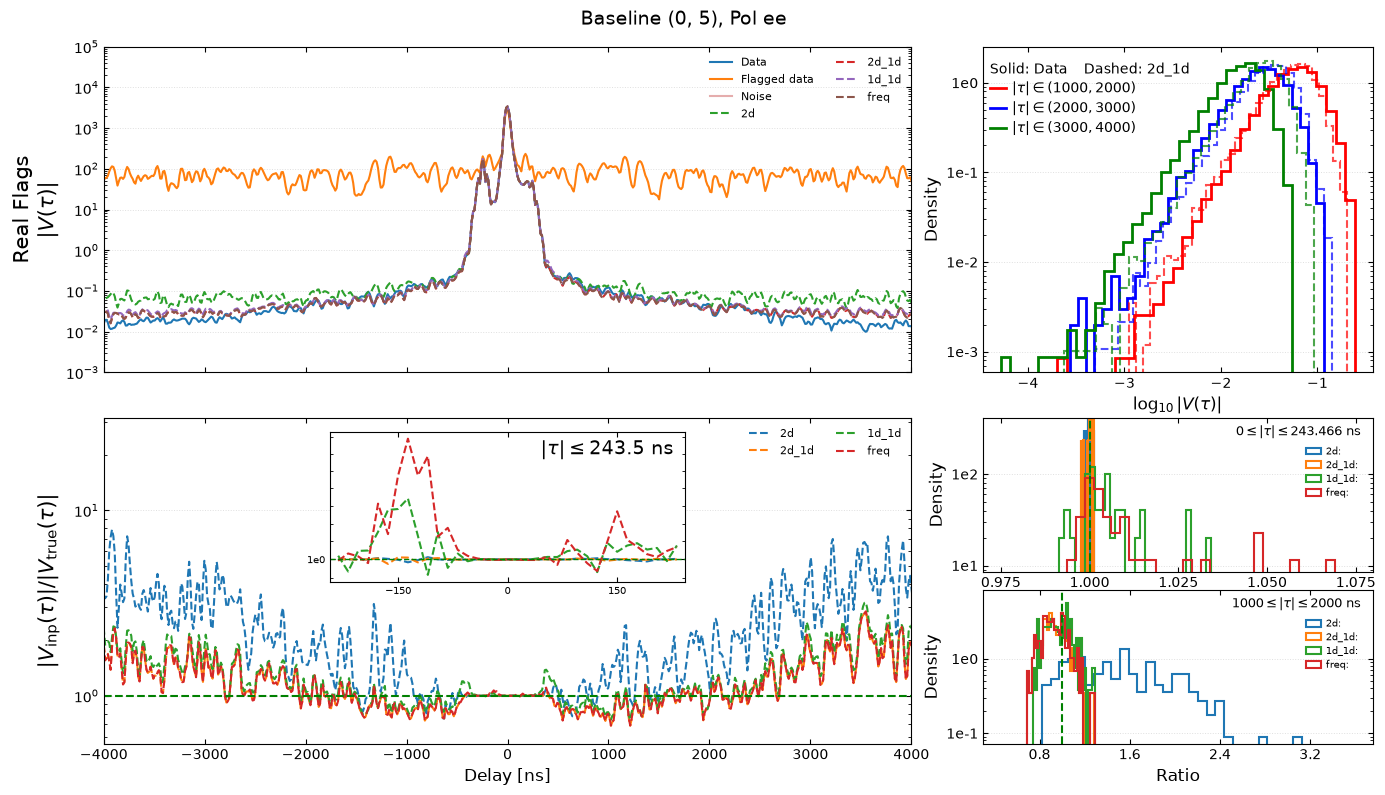

In [5]:
for bl in blall:

    # ========================================================
    # Identify the redundant group and baseline vector
    # ========================================================

    red_ind = np.where([bl in red for red in reds])[0][0]
    bls = reds[red_ind][:]

    representative_bl = bls[0]
    bl_vec = antp[representative_bl[1]] - antp[representative_bl[0]]
    bl_len = bl_vec.norm()

    tau_horizon = get_horizon_delay_ns(bl_len)

    print("\n" + "=" * 70)
    print(f"Baseline: {bl}")
    print(f"Baseline length: {float(bl_len):.3f} m")
    print(f"Horizon delay: {tau_horizon:.3f} ns")
    print("=" * 70)


    # ========================================================
    # Load all baselines in the redundant group
    # ========================================================

    vd, meta = gp_utils.load_uvdata(
        dfile,
        bls=bls,
        time_ints=time_ints,
        freq_chans=freq_chans,
        pols=[polsi],
        device=device,
    )


    # ========================================================
    # Optional modifications
    # ========================================================

    if inflate_data and vd.Nbls == 1:
        vd = vd.inflate_by_redundancy(bls=reds[red_ind])

    if add_reflection:
        reflection = (
            torch.exp(2j * np.pi * 2000e-9 * freqs * 1e6)
            + torch.exp(-2j * np.pi * 2000e-9 * freqs * 1e6)
        )
        vd.data *= 1 + 1e-2 * reflection

    if add_gains:
        gains = torch.randn(vd.Nbls, device=vd.data.device) / 10 + 1
        vd.data *= gains[:, None, None]

    # Noise-only visibility used as a plotting reference.
    ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-10

    if add_noise:
        ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-6
        vd.data += ns_draw


    # ========================================================
    # Fourier transforms
    # ========================================================

    FT1 = FFT(
        dim=-1,
        N=vd.data.shape[-1],
        ndim=2,
        window="bh",
        dx=(freqs[1] - freqs[0]) / 1e3,
    )

    FT2 = FFT(
        dim=-2,
        N=vd.data.shape[-2],
        ndim=2,
        window="bh",
        dx=(lsts[1] - lsts[0]) * 12 / np.pi * 3600 / 1e3,
    )


    # ========================================================
    # Loop over flagging patterns
    # ========================================================

    for flag_idx, flag_typesi in enumerate(flag_types_all):

        flag_types = [flag_typesi]
        flag_N = [20]

        if flag_typesi is None:
            flag_title = "Real Flags" if add_real_flags else "No Flags"
        elif add_real_flags:
            flag_title = (
                "Real Flags + "
                + flag_typesi.replace("_", " ").title()
            )
        else:
            flag_title = flag_typesi.replace("_", " ").title()

        print(f"Plotting: {flag_title}")


        # ----------------------------------------------------
        # Simulated flags
        # ----------------------------------------------------

        flags = gp_utils.simulate_flags(
            flag_types,
            flag_N,
            Ntimes,
            Nfreqs,
            seed=0,
        ).bool()

        if add_gains:
            flags = flags.expand(vd.data.shape[-3:]).clone()

            for i in range(1, vd.Nbls):
                flags[i] = gp_utils.simulate_flags(
                    flag_types,
                    flag_N,
                    Ntimes,
                    Nfreqs,
                    seed=i,
                ).bool()


        # ----------------------------------------------------
        # Add real flags
        # ----------------------------------------------------

        if add_real_flags:
            real_flags = np.load(flag_file)["flags"][
                time_ints
            ][:, freq_chans, 0]

            real_flags = torch.as_tensor(
                real_flags,
                dtype=torch.bool,
                device=device,
            )

            flags = flags | real_flags


        # ----------------------------------------------------
        # Noise variance
        # ----------------------------------------------------

        noise_var = (
            noise_amp.pow(2)
            .expand(flags.shape)
            .clone()
            * 1e-5
        )

        noise_var[flags] = noise_var.mean() * 1e6


        # ====================================================
        # Create figure
        # ====================================================

        (
            fig,
            ax_delay,
            ax_delay_hist,
            ax_ratio,
            ax_ratio_inset,
            ax_ratio_hist_full,
            ax_ratio_hist_horizon,
        ) = create_delay_figure()

        hist_colors = ["r", "b", "g"]
        tau_ranges = [1000, 2000, 3000]

        # Histogram ranges
        full_tmin = 1000.0
        full_tmax = 2000.0

        horizon_tmin = 0.0
        horizon_tmax = tau_horizon

        ratio_hist_full_all = []
        ratio_hist_horizon_all = []


        # ====================================================
        # Loop over inpainting methods
        # ====================================================

        for inpaint_methodi in inpaint_method_all:

            vd_inp = load_vd_inp(
                root_dir=inpaint_root_dir,
                vd=vd,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_methodi,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                device=device,
                Ntime_chunks=Ntime_chunks,
            )


            # ------------------------------------------------
            # Coherent time average
            # ------------------------------------------------

            (
                vd_avg,
                vd_flg_avg,
                vd_inp_avg,
                vd_ns_avg,
            ) = coherent_time_average(
                vd,
                vd_inp,
                flags,
                ns_draw,
                Ntimes,
                Nelem=20,
            )


            # ------------------------------------------------
            # Delay-space quantities
            # ------------------------------------------------

            (
                p_d,
                p_i,
                data_delay,
                flg_delay,
                inp_delay,
                ns_delay,
                delay,
                ratio,
            ) = get_delay_quantities(
                vd_avg,
                vd_flg_avg,
                vd_inp_avg,
                vd_ns_avg,
                FT1,
            )


            # ------------------------------------------------
            # Delay-amplitude histograms
            # ------------------------------------------------

            plot_delay_histograms(
                ax_delay_hist,
                p_d,
                p_i,
                delay,
                inpaint_methodi,
                inpaint_method_all[0],
                tau_ranges,
                hist_colors,
            )


            # ------------------------------------------------
            # Ratio histogram: 0 <= |tau| <= 4000 ns
            # ------------------------------------------------

            ratio_hist_full = get_ratio_hist_values(
                ratio,
                delay,
                tau_min=full_tmin,
                tau_max=full_tmax,
            )

            if ratio_hist_full.size > 0:
                ratio_hist_full_all.append(ratio_hist_full)

            full_method_label = make_ratio_label(
                inpaint_methodi,
                ratio_hist_full,
            )


            # ------------------------------------------------
            # Ratio histogram: 0 <= |tau| <= horizon
            # ------------------------------------------------

            ratio_hist_horizon = get_ratio_hist_values(
                ratio,
                delay,
                tau_min=horizon_tmin,
                tau_max=horizon_tmax,
            )

            if ratio_hist_horizon.size > 0:
                ratio_hist_horizon_all.append(
                    ratio_hist_horizon
                )

            horizon_method_label = make_ratio_label(
                inpaint_methodi,
                ratio_hist_horizon,
            )


            # ------------------------------------------------
            # Reference curves, plotted once
            # ------------------------------------------------

            if inpaint_methodi == inpaint_method_all[0]:
                plot_reference_delay_curves(
                    ax_delay,
                    delay,
                    data_delay,
                    flg_delay,
                    ns_delay,
                )


            # ------------------------------------------------
            # Full delay and ratio curves
            # ------------------------------------------------

            plot_method_curves(
                ax_delay,
                ax_ratio,
                delay,
                inp_delay,
                ratio,
                inpaint_methodi,
            )


            # ------------------------------------------------
            # Horizon inset
            # ------------------------------------------------

            plot_ratio_inset(
                ax_ratio_inset,
                delay,
                ratio,
                inpaint_methodi,
                tau_horizon,
            )


            # ------------------------------------------------
            # Two ratio histograms
            # ------------------------------------------------
            # 上面的 histogram：horizon
            plot_ratio_histogram(
                ax_ratio_hist_full,
                ratio_hist_horizon,
                horizon_method_label,
            )

            # 下面的 histogram：0–4000 ns
            plot_ratio_histogram(
                ax_ratio_hist_horizon,
                ratio_hist_full,
                full_method_label,
            )




        # ====================================================
        # Format all panels
        # ====================================================

        format_delay_axis(
            ax_delay,
            flag_title,
        )

        format_delay_hist_axis(
            ax_delay_hist,
        )

        format_ratio_axis(
            ax_ratio,
            ymin_fraction=0.8,
            ymax_fraction=4,
        )

        format_ratio_inset_axis(
            ax_ratio_inset,
            tau_horizon,
        )


        # 上面：horizon
        format_ratio_hist_axis(
            ax_ratio_hist_full,
            ratio_hist_all=ratio_hist_horizon_all,
            xmin=0.97,
            x_fraction=1.01,
            ymin=0,
            y_fraction=0.1,
            tau_min=horizon_tmin,
            tau_max=horizon_tmax,
            fontsize=7,
            show_xlabel=True,
        )

        # 下面：0–4000 ns
        format_ratio_hist_axis(
            ax_ratio_hist_horizon,
            ratio_hist_all=ratio_hist_full_all,
            xmin=0.3,
            x_fraction=1.2,
            tau_min=full_tmin,
            tau_max=full_tmax,
            fontsize=7,
            show_xlabel=True,
        )
        

        # ====================================================
        # Final layout and display
        # ====================================================

        finalize_delay_figure(
            fig,
            ax_delay,
            ax_ratio,
            flag_idx,
            bl,
            polsi,
        )


In [25]:
1

1

In [57]:
import glob
import importlib
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import gpytorch

from pyuvdata import UVData
import bayeslim as ba
import gprlim
from gprlim import kernels
from bayeslim.fft import FFT


# Local modules
sys.path.append("./")
sys.path.append("../../")

import utils_load
from utils_load import save_vd_inp, load_vd_inp

import gp_utils
importlib.reload(gp_utils)

import utils_Vtau2
importlib.reload(utils_Vtau2)

from utils_Vtau2 import (
    coherent_time_average,
    create_delay_figure,
    get_delay_quantities,
    get_ratio_hist_values,
    get_horizon_delay_ns,
    plot_delay_histograms,
    plot_reference_delay_curves,
    plot_method_curves,
    plot_ratio_inset,
    plot_ratio_histogram,
    make_ratio_label,
    format_delay_axis,
    format_delay_hist_axis,
    format_ratio_axis,
    format_ratio_inset_axis,
    format_ratio_hist_axis,
    finalize_delay_figure,
)


print("gprlim path:")
print(gprlim.__file__)

print("\nutils_load module path:")
print(inspect.getmodule(save_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)

print("\nutils_Vtau2 path:")
print(utils_Vtau2.__file__)


gprlim path:
/Users/alliswell48/gprlim/gprlim/__init__.py

utils_load module path:
/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/utils_load.py

gp_utils path:
/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/../../gp_utils.py

utils_Vtau2 path:
/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/utils_Vtau2.py
